In [1]:
# import libraries
from data_registry import datasets
import pandas as pd
import numpy as np
from statsmodels.gam.api import GLMGam
from statsmodels.gam.api import BSplines
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

# utils functions
from utils.mainutil import to_ts
from utils.m1util import get_spline

# internal plot functions
from plots.ts_plot import ts_plot
from plots.residual_plot import residual_plot

In [10]:
filename = datasets.get("stock")
df = pd.read_csv(filename)

df["Date"] = pd.to_datetime(df["Date"])
df.index = df["Date"]
df = df.drop(columns="Date")

In [ ]:
ts = to_ts(df["Close"])

,ts,pts
Date,,
2020-09-30,9.500000,0.000000
2020-10-01,9.460000,0.000736
2020-10-02,9.200000,0.001473
2020-10-05,9.030000,0.002209
2020-10-06,9.900000,0.002946
...,...,...
2026-02-23,130.600006,0.997054
2026-02-24,128.839996,0.997791
2026-02-25,134.190002,0.998527


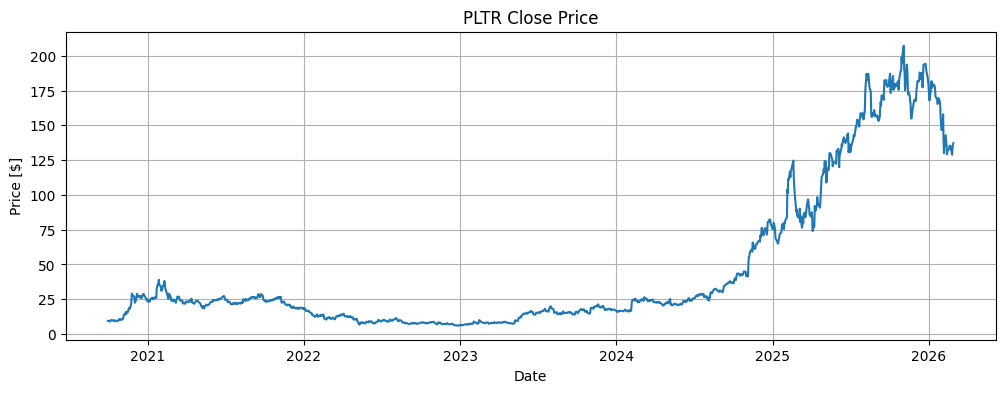

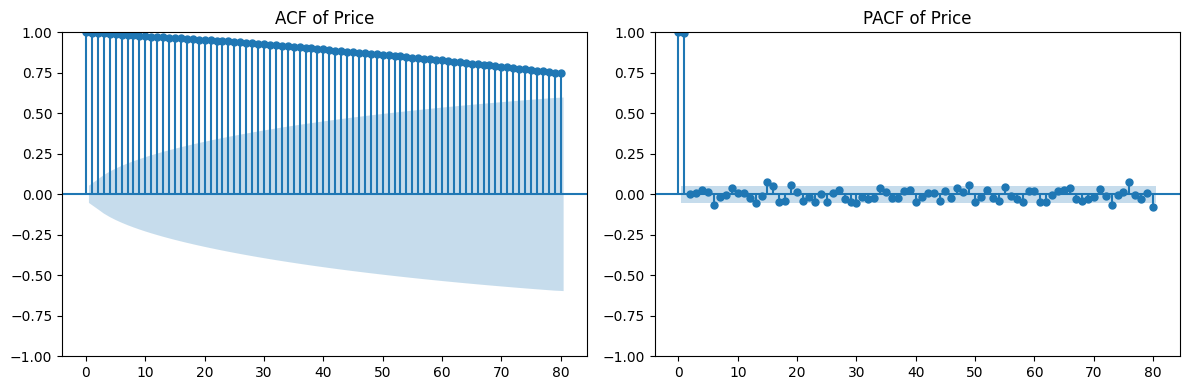

In [20]:
fig = plt.figure(figsize=(12, 4))
plt.plot(ts.index, ts["ts"])
plt.title("PLTR Close Price")
plt.ylabel("Price [$]")
plt.xlabel("Date")
plt.grid(True)
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(ts["ts"] , lags=80, ax=axs[0])
axs[0].set_title("ACF of Price")

plot_pacf(ts["ts"] , lags=80, ax=axs[1], method="ywm")
axs[1].set_title("PACF of Price")

plt.tight_layout()
plt.show()
